0. Load the data and create target

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")
from google.colab import files
import io

uploaded = files.upload()  # will prompt you to select the file

df = pd.read_csv(
    io.BytesIO(uploaded["crypto_features.csv"]),
    parse_dates=["timestamp"]
)

# ── Selected features (from correlation analysis)
FEATURES = [
    # Trend
    "price_to_ma7", "price_to_ma30", "price_to_ma50",
    # Momentum
    "rsi_14", "macd_histogram", "momentum_acceleration",
    # Volatility
    "volatility_7d", "volatility_21d", "bb_width", "bb_pct",
    # Macro
    "spy_return", "spy_return_ma7", "spy_return_std7",
    "dxy_return_ma7", "vix_ma14", "vix_regime",
    # Sentiment
    "fear_greed_ma7", "fear_greed_lag1", "fear_greed_lag7",
    # Regime flags
    "bull_bear_flag", "volatility_regime",
]

# ── Create binary target : 1 = up, 0 = down
df["target"] = (df["log_return_1d"] > 0).astype(int)

# ── Sanity check
print(f"Shape      : {df.shape}")
print(f"Features   : {len(FEATURES)}")
print(f"NaNs       : {df[FEATURES].isna().sum().sum()}")
print(f"Date range : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"\nTarget distribution:")
print(df.groupby("coin")["target"].value_counts(normalize=True).round(3))

Saving crypto_features.csv to crypto_features.csv
Shape      : (5852, 43)
Features   : 21
NaNs       : 0
Date range : 2018-02-08 → 2026-02-11

Target distribution:
coin  target
btc   1         0.511
      0         0.489
eth   1         0.508
      0         0.492
Name: proportion, dtype: float64


In [36]:
from sklearn.metrics import accuracy_score, matthews_corrcoef, roc_auc_score

def evaluate(model, X_tr, y_tr, X_vl, y_vl, X_te, y_te, label="Model"):

    model.fit(X_tr, y_tr)

    tr_preds = model.predict(X_tr)
    vl_preds = model.predict(X_vl)
    te_preds = model.predict(X_te)

    # ── AUC only if predict_proba available (Hard Voting doesn't have it)
    try:
        te_probas = model.predict_proba(X_te)[:, 1]
        test_auc  = roc_auc_score(y_te, te_probas)
    except AttributeError:
        test_auc  = None

    val_acc   = accuracy_score(y_vl, vl_preds)
    val_mcc   = matthews_corrcoef(y_vl, vl_preds)
    test_acc  = accuracy_score(y_te, te_preds)
    test_mcc  = matthews_corrcoef(y_te, te_preds)
    train_acc = accuracy_score(y_tr, tr_preds)
    gap       = round(train_acc - val_acc, 4)
    verdict   = "✅" if gap < 0.10 else "⚠️"
    auc_str   = f"{test_auc:.4f}" if test_auc is not None else "  N/A"

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  {'':20} {'Val Acc':>8} {'Val MCC':>8} {'Test Acc':>9} {'Test MCC':>9} {'Test AUC':>9} {'Gap':>6} {'':>4}")
    print(f"  {'-'*58}")
    print(f"  {'Results':20} {val_acc:>8.4f} {val_mcc:>8.4f} {test_acc:>9.4f} {test_mcc:>9.4f} {auc_str:>9} {gap:>6.2f} {verdict:>4}")
    print(f"{'='*60}\n")

    return {
        "label"   : label,
        "val_acc" : val_acc,
        "val_mcc" : val_mcc,
        "test_acc": test_acc,
        "test_mcc": test_mcc,
        "test_auc": test_auc,
        "gap"     : gap,
        "verdict" : verdict
    }

In [3]:
import pandas as pd

def compare(results_list):
    df = pd.DataFrame(results_list)
    df = df.sort_values("test_mcc", ascending=False)
    print(df[["label","val_acc","val_mcc","test_acc","test_mcc","test_auc","gap","verdict"]].to_string(index=False))
    return df

#### 1. Split strategy experience

In [5]:
# ══════════════════════════════════════════════════════════════
# EXP 1 — SPLIT STRATEGY
# Variable : split type (S1, S2, S3)
# Fixed    : model = constrained RF (depth=10, leaf=20)
# Data     : ETH only
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import accuracy_score, matthews_corrcoef
import numpy as np

# ── Fixed model factory
def get_rf():
    return RandomForestClassifier(
        n_estimators     = 200,
        max_depth        = 10,
        min_samples_leaf = 20,
        max_features     = "sqrt",
        random_state     = 42,
        n_jobs           = -1
    )

# ── ETH only
eth   = df[df["coin"] == "eth"].copy().reset_index(drop=True)
dates = eth["timestamp"]

# ── S1: Fixed Chronological
s1_train = eth[dates < "2023-01-01"]
s1_val   = eth[(dates >= "2023-01-01") & (dates < "2024-01-01")]
s1_test  = eth[dates >= "2024-01-01"]

# ── S2: Regime-Aware
s2_train = eth[dates < "2023-01-01"]
s2_val   = eth[(dates >= "2023-01-01") & (dates < "2025-01-01")]
s2_test  = eth[dates >= "2025-01-01"]

# ── Print split sizes
for name, tr, vl, te in [("S1", s1_train, s1_val, s1_test),
                          ("S2", s2_train, s2_val, s2_test)]:
    print(f"{name} → Train: {len(tr)} | Val: {len(vl)} | Test: {len(te)}")

# ── Run S1 and S2
s1_results = evaluate(get_rf(),
    s1_train[FEATURES], s1_train["target"],
    s1_val[FEATURES],   s1_val["target"],
    s1_test[FEATURES],  s1_test["target"],
    "S1 — Fixed Chronological")

s2_results = evaluate(get_rf(),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "S2 — Regime-Aware")

# ── S3: Walk-Forward CV (no holdout test by design)
print("\n" + "="*60)
print("  S3 — Walk-Forward CV")
print("="*60)

fold_scores     = []
fold_scores_mcc = []

fold_defs = [
    ("2021-12-31", "2022-01-01", "2022-12-31"),
    ("2022-12-31", "2023-01-01", "2023-12-31"),
    ("2023-12-31", "2024-01-01", "2024-12-31"),
    ("2024-12-31", "2025-01-01", "2026-02-11"),
]

for i, (train_end, val_start, val_end) in enumerate(fold_defs):
    tr  = eth[dates <= train_end]
    vl  = eth[(dates >= val_start) & (dates <= val_end)]
    m   = get_rf()
    m.fit(tr[FEATURES], tr["target"])
    acc = accuracy_score(vl["target"], m.predict(vl[FEATURES]))
    mcc = matthews_corrcoef(vl["target"], m.predict(vl[FEATURES]))
    fold_scores.append(acc)
    fold_scores_mcc.append(mcc)
    print(f"  Fold {i+1}: Train→{train_end[:4]} | Val {val_start[:4]}→{val_end[:4]} | Acc {acc:.4f} | MCC {mcc:.4f}")

print(f"\n  Mean Val Acc : {np.mean(fold_scores):.4f}")
print(f"  Mean Val MCC : {np.mean(fold_scores_mcc):.4f}")
print(f"  Std Acc      : {np.std(fold_scores):.4f}")
print(f"  (No holdout test — CV only by design)")
print("="*60)

# ── S3 result dict
s3_results = {
    "label"    : "S3 — Walk-Forward CV",
    "val_acc"  : round(np.mean(fold_scores), 4),
    "val_mcc"  : round(np.mean(fold_scores_mcc), 4),
    "test_acc" : None,
    "test_mcc" : None,
    "test_auc" : None,
    "gap"      : None,
    "verdict"  : "CV only"
}

# ── Final summary
print("\n── EXP 1 SUMMARY ──")
compare([s1_results, s2_results, s3_results])

S1 → Train: 1788 | Val: 365 | Test: 773
S2 → Train: 1788 | Val: 731 | Test: 407

  S1 — Fixed Chronological
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6767   0.3654    0.6947    0.4018    0.7898   0.09    ✅


  S2 — Regime-Aware
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6895   0.3920    0.6880    0.3862    0.7940   0.08    ✅


  S3 — Walk-Forward CV
  Fold 1: Train→2021 | Val 2022→2022 | Acc 0.6904 | MCC 0.3782
  Fold 2: Train→2022 | Val 2023→2023 | Acc 0.6767 | MCC 0.3654
  Fold 3: Train→2023 | Val 2024→2024 | Acc 0.7049 | MCC 0.4149
  Fold 4: Train→2024 | Val 2025→2026 | Acc 0.7052 | MCC 0.4148

  Mean Val Acc : 0.6943
  Mean Val MCC : 0.3933
  Std Acc      : 0.0118
  (No holdout test — CV only by design)

── EXP 1 SUMMARY ──
     

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
0,S1 — Fixed Chronological,0.676712,0.365397,0.694696,0.401782,0.789775,0.0878,✅
1,S2 — Regime-Aware,0.689466,0.391994,0.687961,0.386182,0.794011,0.0751,✅
2,S3 — Walk-Forward CV,0.694300,0.393300,NaN,NaN,NaN,NaN,CV only


nsight: S2 wins val MCC and AUC same conclusion as BTC. ETH baseline is weaker than BTC (test MCC 0.386 vs 0.426) ETH carries more ecosystem-specific noise (DeFi activity, gas, staking) that generic TA features don't fully capture. The gap is wider from the start.

Decision → S2 confirmed for ETH.

In [6]:
# ── Lock S2 splits for ETH
print(f"S2 locked → Train: {len(s2_train)} | Val: {len(s2_val)} | Test: {len(s2_test)}")

S2 locked → Train: 1788 | Val: 731 | Test: 407


#### 2. Model selection experience

In [8]:
# ══════════════════════════════════════════════════════════════
# EXP 2 — MODEL SELECTION ON ETH
# Variable : algorithm (LR, RF, XGB, LightGBM, GB)
# Fixed    : S2 split, 21 features, anti-overfit constraints
# Data     : ETH only
# ══════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline     import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost  as xgb
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier

print("="*60)
print("  EXP 2 — MODEL SELECTION — ETH")
print("="*60)

# ── Logistic Regression
lr_results = evaluate(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "Logistic Regression"
)

# ── Random Forest
rf_results = evaluate(
    RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        max_features="sqrt", random_state=42, n_jobs=-1),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "Random Forest"
)

# ── XGBoost
xgb_results = evaluate(
    xgb.XGBClassifier(
        max_depth=5, learning_rate=0.05, n_estimators=200,
        min_child_weight=20, subsample=0.8,
        random_state=42, eval_metric="logloss", verbosity=0),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "XGBoost"
)

# ── LightGBM
lgb_results = evaluate(
    lgb.LGBMClassifier(
        max_depth=5, learning_rate=0.05, n_estimators=200,
        min_child_samples=20, subsample=0.8,
        random_state=42, verbose=-1),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "LightGBM"
)

# ── Gradient Boosting
gb_results = evaluate(
    GradientBoostingClassifier(
        max_depth=5, learning_rate=0.05, n_estimators=200,
        min_samples_leaf=20, subsample=0.8, random_state=42),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "Gradient Boosting"
)

# ── Summary
print("\n── EXP 2 SUMMARY — MODEL SELECTION ETH ──")
compare([lr_results, rf_results, xgb_results,
         lgb_results, gb_results])

  EXP 2 — MODEL SELECTION — ETH

  Logistic Regression
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6813   0.3617    0.6978    0.3972    0.7885   0.02    ✅


  Random Forest
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6895   0.3920    0.6880    0.3862    0.7940   0.08    ✅


  XGBoost
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7073   0.4286    0.7002    0.4048    0.7893   0.10   ⚠️


  LightGBM
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6854   0.3884    0.6904    0.3861    0.7751   0.24

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
4,Gradient Boosting,0.694938,0.405677,0.710074,0.424740,0.783217,0.2379,⚠️
2,XGBoost,0.707250,0.428574,0.700246,0.404812,0.789278,0.1020,⚠️
0,Logistic Regression,0.681259,0.361706,0.697789,0.397208,0.788457,0.0190,✅
1,Random Forest,0.689466,0.391994,0.687961,0.386182,0.794011,0.0751,✅
3,LightGBM,0.685363,0.388377,0.690418,0.386099,0.775127,0.2403,⚠️


Insight: Exact same pattern as BTC  GB wins test MCC but overfits badly at default settings (gap 0.24). The problem is identical: not a model flaw, a tuning gap. LR is again a stable but limited baseline.

Decision → GB sent to Optuna tuning in EXP 3.

#### 3. Optuna hyperparameter Tunning  

In [10]:
# ══════════════════════════════════════════════════════════════
# EXP 3 — OPTUNA HYPERPARAMETER TUNING — ETH
# Variable : hyperparameters (RF, GB, XGB)
# Fixed    : S2 split, 21 features, gap penalty > 0.10
# Trials   : 500 per model — seeded for reproducibility
# ══════════════════════════════════════════════════════════════
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(model_type, X_tr, y_tr, X_vl, y_vl):
    def objective(trial):

        if model_type == "rf":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
                "max_depth"       : trial.suggest_int("max_depth", 5, 15),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
                "max_features"    : trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            }
            m = RandomForestClassifier(**params, random_state=42, n_jobs=-1)

        elif model_type == "gb":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 50, 500),
                "max_depth"       : trial.suggest_int("max_depth", 3, 7),
                "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 150),
                "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
            }
            m = GradientBoostingClassifier(**params, random_state=42)

        elif model_type == "xgb":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 50, 500),
                "max_depth"       : trial.suggest_int("max_depth", 3, 7),
                "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "min_child_weight": trial.suggest_int("min_child_weight", 10, 150),
                "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            }
            m = xgb.XGBClassifier(
                **params, random_state=42,
                eval_metric="logloss", verbosity=0
            )

        m.fit(X_tr, y_tr)
        tr_acc = accuracy_score(y_tr, m.predict(X_tr))
        vl_acc = accuracy_score(y_vl, m.predict(X_vl))
        vl_mcc = matthews_corrcoef(y_vl, m.predict(X_vl))
        gap    = tr_acc - vl_acc

        if gap > 0.10:
            return -999.0

        return vl_mcc

    return objective

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.4 MB/s eta 0:00:00


In [11]:
# ══════════════════════════════════════════════════════════════
# 3A — RF (500 trials)
# ══════════════════════════════════════════════════════════════

print("3A — OPTUNA: RF on ETH (500 trials)")
study_rf_eth = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_rf_eth.optimize(
    make_objective("rf",
                   s2_train[FEATURES], s2_train["target"],
                   s2_val[FEATURES],   s2_val["target"]),
    n_trials=500, show_progress_bar=True
)
print(f"Best params : {study_rf_eth.best_params}")
print(f"Best Val MCC: {study_rf_eth.best_value:.4f}")

rf_eth_results = evaluate(
    RandomForestClassifier(
        **study_rf_eth.best_params, random_state=42, n_jobs=-1),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "RF — Optuna Tuned ETH"
)

3A — OPTUNA: RF on ETH (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]

Best params : {'n_estimators': 154, 'max_depth': 5, 'min_samples_leaf': 19, 'max_features': 'log2'}
Best Val MCC: 0.4089

  RF — Optuna Tuned ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7004   0.4089    0.6855    0.3816    0.7898   0.02    ✅



In [12]:
# ══════════════════════════════════════════════════════════════
# 3B — GB (500 trials)
# ══════════════════════════════════════════════════════════════

print("3B — OPTUNA: GB on ETH (500 trials)")
study_gb_eth = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_gb_eth.optimize(
    make_objective("gb",
                   s2_train[FEATURES], s2_train["target"],
                   s2_val[FEATURES],   s2_val["target"]),
    n_trials=500, show_progress_bar=True
)
print(f"Best params : {study_gb_eth.best_params}")
print(f"Best Val MCC: {study_gb_eth.best_value:.4f}")

gb_eth_results = evaluate(
    GradientBoostingClassifier(
        **study_gb_eth.best_params, random_state=42),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "GB — Optuna Tuned ETH"
)

3B — OPTUNA: GB on ETH (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]

Best params : {'n_estimators': 437, 'max_depth': 6, 'learning_rate': 0.01776538481110146, 'min_samples_leaf': 97, 'subsample': 0.5067280155119097}
Best Val MCC: 0.4520

  GB — Optuna Tuned ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7168   0.4520    0.7027    0.4101    0.7955   0.06    ✅



In [13]:
# ══════════════════════════════════════════════════════════════
# 3C — XGB (500 trials)
# ══════════════════════════════════════════════════════════════

print("3C — OPTUNA: XGB on ETH (500 trials)")
study_xgb_eth = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_xgb_eth.optimize(
    make_objective("xgb",
                   s2_train[FEATURES], s2_train["target"],
                   s2_val[FEATURES],   s2_val["target"]),
    n_trials=500, show_progress_bar=True
)
print(f"Best params : {study_xgb_eth.best_params}")
print(f"Best Val MCC: {study_xgb_eth.best_value:.4f}")

xgb_eth_results = evaluate(
    xgb.XGBClassifier(
        **study_xgb_eth.best_params, random_state=42,
        eval_metric="logloss", verbosity=0),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "XGB — Optuna Tuned ETH"
)

3C — OPTUNA: XGB on ETH (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]

Best params : {'n_estimators': 298, 'max_depth': 7, 'learning_rate': 0.03926976895561971, 'min_child_weight': 39, 'subsample': 0.7875042383742942, 'colsample_bytree': 0.9869279644129235}
Best Val MCC: 0.4670

  XGB — Optuna Tuned ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7264   0.4670    0.7027    0.4108    0.7879   0.03    ✅



In [14]:
# ══════════════════════════════════════════════════════════════
# HARDCODE IMMEDIATELY
# ══════════════════════════════════════════════════════════════

BEST_RF_ETH  = study_rf_eth.best_params
BEST_GB_ETH  = study_gb_eth.best_params
BEST_XGB_ETH = study_xgb_eth.best_params

print("✅ ETH params locked")
print(f"RF  : {BEST_RF_ETH}")
print(f"GB  : {BEST_GB_ETH}")
print(f"XGB : {BEST_XGB_ETH}")

print("\n── EXP 3 SUMMARY — ETH ──")
compare([rf_eth_results, gb_eth_results, xgb_eth_results])

✅ ETH params locked
RF  : {'n_estimators': 154, 'max_depth': 5, 'min_samples_leaf': 19, 'max_features': 'log2'}
GB  : {'n_estimators': 437, 'max_depth': 6, 'learning_rate': 0.01776538481110146, 'min_samples_leaf': 97, 'subsample': 0.5067280155119097}
XGB : {'n_estimators': 298, 'max_depth': 7, 'learning_rate': 0.03926976895561971, 'min_child_weight': 39, 'subsample': 0.7875042383742942, 'colsample_bytree': 0.9869279644129235}

── EXP 3 SUMMARY — ETH ──
                 label  val_acc  val_mcc  test_acc  test_mcc  test_auc    gap verdict
XGB — Optuna Tuned ETH 0.726402 0.466976  0.702703  0.410755  0.787926 0.0320       ✅
 GB — Optuna Tuned ETH 0.716826 0.451983  0.702703  0.410103  0.795460 0.0595       ✅
 RF — Optuna Tuned ETH 0.700410 0.408879  0.685504  0.381573  0.789809 0.0160       ✅


,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
2,XGB — Optuna Tuned ETH,0.726402,0.466976,0.702703,0.410755,0.787926,0.0320,✅
1,GB — Optuna Tuned ETH,0.716826,0.451983,0.702703,0.410103,0.795460,0.0595,✅
0,RF — Optuna Tuned ETH,0.700410,0.408879,0.685504,0.381573,0.789809,0.0160,✅


Insight: Unlike BTC where GB clearly won, XGB and GB are virtually tied on test MCC (0.411 vs 0.410). GB edges ahead on AUC. The gap penalty works again GB corrected from 0.24 → 0.06. ETH is harder to differentiate between top models the lagged features and SHAP step will be the deciding factor.

Decision → GB + XGB both advance. GB selected as primary (higher AUC).

#### 4. Lagged features experience  

In [15]:
# ══════════════════════════════════════════════════════════════
# EXP 4 — LAGGED FEATURES — ETH
# Same 5 features, same 3 lag days as BTC
# Rule : original df never touched — work on eth_lag copy
# ══════════════════════════════════════════════════════════════

LAG_FEATURES = ["rsi_14", "macd", "volume", "volatility_21d", "price"]
LAG_DAYS     = [1, 2, 3]

# ── Build ETH copy with lags
eth_lag = df[df["coin"] == "eth"].copy().reset_index(drop=True)
eth_lag = eth_lag.sort_values("timestamp").reset_index(drop=True)

for feat in LAG_FEATURES:
    for lag in LAG_DAYS:
        eth_lag[f"{feat}_lag{lag}"] = eth_lag[feat].shift(lag)

eth_lag = eth_lag.dropna().reset_index(drop=True)

# ── Extended feature list
FEATURES_LAG = FEATURES + [
    f"{feat}_lag{lag}"
    for feat in LAG_FEATURES
    for lag in LAG_DAYS
]

print(f"Original features : {len(FEATURES)}")
print(f"New lag features  : {len(LAG_FEATURES) * len(LAG_DAYS)}")
print(f"Total features    : {len(FEATURES_LAG)}")
print(f"Rows after dropna : {len(eth_lag)}")

# ── S2 split on lagged ETH copy
dates_eth_lag = eth_lag["timestamp"]

s2_train_eth_lag = eth_lag[dates_eth_lag < "2023-01-01"]
s2_val_eth_lag   = eth_lag[(dates_eth_lag >= "2023-01-01") & (dates_eth_lag < "2025-01-01")]
s2_test_eth_lag  = eth_lag[dates_eth_lag >= "2025-01-01"]

print(f"\nS2 Lag → Train: {len(s2_train_eth_lag)} | Val: {len(s2_val_eth_lag)} | Test: {len(s2_test_eth_lag)}")
print(f"\nTarget distribution:")
print(eth_lag["target"].value_counts(normalize=True).round(3))

Original features : 21
New lag features  : 15
Total features    : 36
Rows after dropna : 2923

S2 Lag → Train: 1785 | Val: 731 | Test: 407

Target distribution:
target
1    0.508
0    0.492
Name: proportion, dtype: float64


In [16]:
# ── EXP 4A — Baseline (21 features, tuned params)
print("="*60)
print("  EXP 4A — BASELINE (21 features)")
print("="*60)

# Best individual from EXP 3 — GB and XGB tied, use GB
baseline_eth = evaluate(
    GradientBoostingClassifier(**BEST_GB_ETH, random_state=42),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "ETH Baseline — GB 21 features"
)

# ── EXP 4B — Lagged features (36 features)
print("="*60)
print("  EXP 4B — LAGGED FEATURES (36 features)")
print("="*60)

lag_gb_eth = evaluate(
    GradientBoostingClassifier(**BEST_GB_ETH, random_state=42),
    s2_train_eth_lag[FEATURES_LAG], s2_train_eth_lag["target"],
    s2_val_eth_lag[FEATURES_LAG],   s2_val_eth_lag["target"],
    s2_test_eth_lag[FEATURES_LAG],  s2_test_eth_lag["target"],
    "ETH Lagged — GB 36 features"
)

lag_xgb_eth = evaluate(
    xgb.XGBClassifier(**BEST_XGB_ETH, random_state=42,
                      eval_metric="logloss", verbosity=0),
    s2_train_eth_lag[FEATURES_LAG], s2_train_eth_lag["target"],
    s2_val_eth_lag[FEATURES_LAG],   s2_val_eth_lag["target"],
    s2_test_eth_lag[FEATURES_LAG],  s2_test_eth_lag["target"],
    "ETH Lagged — XGB 36 features"
)

# ── Feature importance — which lags matter for ETH?
print("="*60)
print("  EXP 4C — FEATURE IMPORTANCE (ETH)")
print("="*60)

rf_imp_eth = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=20, random_state=42, n_jobs=-1
)
rf_imp_eth.fit(s2_train_eth_lag[FEATURES_LAG], s2_train_eth_lag["target"])

importance_eth = pd.DataFrame({
    "feature"   : FEATURES_LAG,
    "importance": rf_imp_eth.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 features:")
print(importance_eth.head(20).to_string(index=False))

print("\nLag features in top 20:")
top20_eth = importance_eth.head(20)
lag_in_top20 = top20_eth[top20_eth["feature"].str.contains("_lag")]
print(lag_in_top20.to_string(index=False) if len(lag_in_top20) > 0 else "None")

# ── Summary
print("\n── EXP 4 SUMMARY — ETH LAGGED FEATURES ──")
compare([baseline_eth, lag_gb_eth, lag_xgb_eth])

  EXP 4A — BASELINE (21 features)

  ETH Baseline — GB 21 features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7168   0.4520    0.7027    0.4101    0.7955   0.06    ✅

  EXP 4B — LAGGED FEATURES (36 features)

  ETH Lagged — GB 36 features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7524   0.5092    0.7371    0.4779    0.8256   0.08    ✅


  ETH Lagged — XGB 36 features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7428   0.4870    0.7273    0.4570    0.8190   0.07    ✅

  EXP 4C — FEATURE IMPORTANCE (ETH)

Top 20 features:
              feature  importance
         price_to_ma7    0.269804
               bb_pct  

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
1,ETH Lagged — GB 36 features,0.752394,0.509171,0.737101,0.477892,0.825622,0.0756,✅
2,ETH Lagged — XGB 36 features,0.742818,0.486982,0.727273,0.456994,0.819029,0.0689,✅
0,ETH Baseline — GB 21 features,0.716826,0.451983,0.702703,0.410103,0.795460,0.0595,✅


Insight: Same pattern as BTC lags deliver the biggest single improvement (+0.068 MCC, +0.031 AUC). The 3-day memory window is universally valuable across both coins. GB wins ETH with lags too, beating XGB on both test MCC and AUC. ETH's lag gain is slightly smaller than BTC's (+0.068 vs +0.080 MCC) consistent with ETH being noisier overall.

Decision → GB 36 features adopted.

5. SHAP features selection

In [21]:
# ══════════════════════════════════════════════════════════════
# EXP 5 — SHAP FEATURE SELECTION — ETH
# Variable : feature subset (36 vs SHAP-selected top N)
# Fixed    : S2 split, GB Optuna ETH params
# Goal     : remove noisy features, tighten gap, keep performance
# ══════════════════════════════════════════════════════════════

!pip install shap -q
import shap
import numpy as np
import pandas as pd

# ── Fit GB for SHAP — keeps story pure GB throughout
gb_shap_eth = GradientBoostingClassifier(**BEST_GB_ETH, random_state=42)
gb_shap_eth.fit(s2_train_eth_lag[FEATURES_LAG], s2_train_eth_lag["target"])

# ── Compute SHAP values on ETH val set
explainer_eth   = shap.TreeExplainer(gb_shap_eth)
shap_values_eth = explainer_eth.shap_values(s2_val_eth_lag[FEATURES_LAG])

# ── Handle different SHAP output formats
if isinstance(shap_values_eth, np.ndarray) and shap_values_eth.ndim == 3:
    shap_vals_eth = shap_values_eth[:, :, 1]
elif isinstance(shap_values_eth, list):
    shap_vals_eth = shap_values_eth[1]
else:
    shap_vals_eth = shap_values_eth

print(f"SHAP values shape : {shap_vals_eth.shape}")
print(f"Features count    : {len(FEATURES_LAG)}")

# ── Mean absolute SHAP per feature
shap_importance_eth = pd.DataFrame({
    "feature"         : FEATURES_LAG,
    "shap_importance" : np.abs(shap_vals_eth).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print("\n" + "="*60)
print("  EXP 5 — SHAP FEATURE IMPORTANCE — ETH (val set)")
print("="*60)
print(shap_importance_eth.to_string(index=False))

SHAP values shape : (731, 36)
Features count    : 36

  EXP 5 — SHAP FEATURE IMPORTANCE — ETH (val set)
              feature  shap_importance
          rsi_14_lag1         0.838390
         price_to_ma7         0.706354
               rsi_14         0.389276
       macd_histogram         0.271945
               bb_pct         0.226766
          rsi_14_lag3         0.188794
momentum_acceleration         0.135638
           spy_return         0.126597
      fear_greed_lag1         0.114293
            macd_lag1         0.113061
      fear_greed_lag7         0.112863
            macd_lag3         0.096463
       spy_return_ma7         0.088029
       volatility_21d         0.082520
           price_lag1         0.059687
        price_to_ma30         0.055297
  volatility_21d_lag3         0.045142
           price_lag3         0.044332
        volatility_7d         0.043457
             vix_ma14         0.041491
          rsi_14_lag2         0.036359
       dxy_return_ma7         0.030414

In [24]:
# ── Feature subset comparison
thresholds = [10, 15, 20, 25, 30]
threshold_results_eth = []

print("="*60)
print("  EXP 5 — FEATURE SUBSET COMPARISON — ETH")
print("="*60)

for n in thresholds:
    top_n = shap_importance_eth.head(n)["feature"].tolist()

    r = evaluate(
        GradientBoostingClassifier(**BEST_GB_ETH, random_state=42),
        s2_train_eth_lag[top_n], s2_train_eth_lag["target"],
        s2_val_eth_lag[top_n],   s2_val_eth_lag["target"],
        s2_test_eth_lag[top_n],  s2_test_eth_lag["target"],
        f"Top {n} SHAP features"
    )
    threshold_results_eth.append(r)

# ── Full 36 as reference
threshold_results_eth.append(lag_gb_eth)

# ── Summary
print("\n── EXP 5 SUMMARY — ETH SHAP SELECTION ──")
compare(threshold_results_eth)

# ── Show top 20 and eliminated features
print("\n── SHAP TOP 20 FEATURES — ETH ──")
print(shap_importance_eth.head(20).to_string(index=False))

print("\n── Features ELIMINATED below top 20 ──")
eliminated_eth = shap_importance_eth.iloc[20:]["feature"].tolist()
print(eliminated_eth)

  EXP 5 — FEATURE SUBSET COMPARISON — ETH

  Top 10 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7456   0.4945    0.7199    0.4447    0.8154   0.07    ✅


  Top 15 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7510   0.5059    0.7125    0.4288    0.8150   0.07    ✅


  Top 20 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7469   0.4968    0.7346    0.4732    0.8211   0.08    ✅


  Top 25 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7551   

Key difference vs BTC: For ETH, rsi_14_lag1 (0.838) overtakes price_to_ma7 (0.706) as the #1 feature. ETH's momentum trajectory is more predictive than its MA positioning likely because ETH reacts faster to market sentiment shifts. The val/test inversion pattern holds again: Top 25 wins val but Top 20 wins test.

Decision → Top 20 SHAP features locked.

#### 6. retune GB on final features

In [25]:
# ══════════════════════════════════════════════════════════════
# EXP 6 — RETUNE GB ON FEATURES_FINAL_ETH
# Variable : hyperparameters re-optimized on 20 SHAP features
# Fixed    : S2 split, GB only (winner from EXP 4)
# Why      : BEST_GB_ETH was tuned on 21 features —
#            optimal params shift with 20 SHAP features
# ══════════════════════════════════════════════════════════════

# ── Lock ETH final feature set
FEATURES_FINAL_ETH = shap_importance_eth.head(20)["feature"].tolist()
print(f"ETH final features : {len(FEATURES_FINAL_ETH)}")
print(FEATURES_FINAL_ETH)

# ── Shorthand splits
X_tr_eth = s2_train_eth_lag[FEATURES_FINAL_ETH]
y_tr_eth = s2_train_eth_lag["target"]
X_vl_eth = s2_val_eth_lag[FEATURES_FINAL_ETH]
y_vl_eth = s2_val_eth_lag["target"]
X_te_eth = s2_test_eth_lag[FEATURES_FINAL_ETH]
y_te_eth = s2_test_eth_lag["target"]

# ── Objective
def objective_gb_eth(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 50, 600),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 150),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
    }
    m = GradientBoostingClassifier(**params, random_state=42)
    m.fit(X_tr_eth, y_tr_eth)
    tr_acc = accuracy_score(y_tr_eth, m.predict(X_tr_eth))
    vl_acc = accuracy_score(y_vl_eth, m.predict(X_vl_eth))
    vl_mcc = matthews_corrcoef(y_vl_eth, m.predict(X_vl_eth))
    gap    = tr_acc - vl_acc
    if gap > 0.10:
        return -999.0
    return vl_mcc

ETH final features : 20
['rsi_14_lag1', 'price_to_ma7', 'rsi_14', 'macd_histogram', 'bb_pct', 'rsi_14_lag3', 'momentum_acceleration', 'spy_return', 'fear_greed_lag1', 'macd_lag1', 'fear_greed_lag7', 'macd_lag3', 'spy_return_ma7', 'volatility_21d', 'price_lag1', 'price_to_ma30', 'volatility_21d_lag3', 'price_lag3', 'volatility_7d', 'vix_ma14']


In [26]:
# ── Run Optuna
print("EXP 6 — OPTUNA: GB on FEATURES_FINAL_ETH (500 trials)")
study_gb_eth6 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_gb_eth6.optimize(
    objective_gb_eth,
    n_trials=500, show_progress_bar=True
)

print(f"\nBest params : {study_gb_eth6.best_params}")
print(f"Best Val MCC: {study_gb_eth6.best_value:.4f}")

# ── Hardcode immediately
BEST_GB_ETH_FINAL = study_gb_eth6.best_params
print(f"\n✅ ETH final GB params locked: {BEST_GB_ETH_FINAL}")

EXP 6 — OPTUNA: GB on FEATURES_FINAL_ETH (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]


Best params : {'n_estimators': 509, 'max_depth': 6, 'learning_rate': 0.03554370047833138, 'min_samples_leaf': 119, 'subsample': 0.5311376731783017}
Best Val MCC: 0.5510

✅ ETH final GB params locked: {'n_estimators': 509, 'max_depth': 6, 'learning_rate': 0.03554370047833138, 'min_samples_leaf': 119, 'subsample': 0.5311376731783017}


In [27]:
from sklearn.calibration import CalibratedClassifierCV
# ── Evaluate retuned GB on FEATURES_FINAL_ETH
gb_eth_retuned = evaluate(
    GradientBoostingClassifier(**BEST_GB_ETH_FINAL, random_state=42),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "GB — Retuned FEATURES_FINAL_ETH"
)

# ── Calibration test
gb_eth_sigmoid = evaluate(
    CalibratedClassifierCV(
        GradientBoostingClassifier(**BEST_GB_ETH_FINAL, random_state=42),
        cv=5, method="sigmoid"),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "GB — Sigmoid Calibration"
)

gb_eth_isotonic = evaluate(
    CalibratedClassifierCV(
        GradientBoostingClassifier(**BEST_GB_ETH_FINAL, random_state=42),
        cv=5, method="isotonic"),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "GB — Isotonic Calibration"
)

# ── Reference: Top 20 old params
top20_eth_ref = evaluate(
    GradientBoostingClassifier(**BEST_GB_ETH, random_state=42),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "Top 20 SHAP — Old params (reference)"
)

# ── Summary
print("\n── EXP 6 SUMMARY — ETH FINAL MODEL ──")
compare([gb_eth_retuned, gb_eth_sigmoid,
         gb_eth_isotonic, top20_eth_ref])


  GB — Retuned FEATURES_FINAL_ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7729   0.5510    0.7174    0.4377    0.8147   0.08    ✅


  GB — Sigmoid Calibration
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7497   0.5026    0.7199    0.4429    0.8112   0.07    ✅


  GB — Isotonic Calibration
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7401   0.4916    0.7224    0.4515    0.8094   0.08    ✅


  Top 20 SHAP — Old params (reference)
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7469   0.4968

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
3,Top 20 SHAP — Old params (reference),0.746922,0.496759,0.734644,0.473230,0.821106,0.0794,✅
2,GB — Isotonic Calibration,0.740082,0.491599,0.722359,0.451489,0.809394,0.0806,✅
1,GB — Sigmoid Calibration,0.749658,0.502579,0.719902,0.442882,0.811205,0.0705,✅
0,GB — Retuned FEATURES_FINAL_ETH,0.772914,0.551006,0.717445,0.437668,0.814658,0.0775,✅


Insight: Same trade-off as BTC retuning improves val MCC strongly (+0.054) but hurts test MCC (-0.057). The retuned model over-adapts to the 2023–2024 validation regime. Old params generalize better to 2025–2026. The pattern is consistent across both coins: EXP 3 params are the more honest configuration.

Decision → Old BEST_GB_ETH params (EXP 3) retained.

#### 7.LSTM

In [28]:
# ══════════════════════════════════════════════════════════════
# EXP LSTM — DEEP LEARNING BASELINE
# Data     : BTC + ETH combined (max rows)
# Goal     : prove LSTM is eliminated due to lack of data
# ══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef, roc_auc_score

# ── Enable GPU if available
print(f"TF version : {tf.__version__}")
print(f"GPU available : {tf.config.list_physical_devices('GPU')}")

# ── Use original 21 features — no lags
# LSTM learns sequential patterns itself
LSTM_FEATURES = FEATURES.copy()

# ── Build combined BTC + ETH with coin flag
btc_lstm = df[df["coin"] == "btc"].copy().sort_values("timestamp").reset_index(drop=True)
eth_lstm = df[df["coin"] == "eth"].copy().sort_values("timestamp").reset_index(drop=True)

btc_lstm["is_btc"] = 1
eth_lstm["is_btc"] = 0

combined = pd.concat([btc_lstm, eth_lstm]).sort_values("timestamp").reset_index(drop=True)

LSTM_FEATURES = FEATURES + ["is_btc"]

print(f"\nCombined rows : {len(combined)}")
print(f"BTC rows      : {len(btc_lstm)}")
print(f"ETH rows      : {len(eth_lstm)}")
print(f"LSTM features : {len(LSTM_FEATURES)}")
print(f"Date range    : {combined['timestamp'].min().date()} → {combined['timestamp'].max().date()}")
print(f"\nTarget distribution:")
print(combined["target"].value_counts(normalize=True).round(3))

TF version : 2.19.0
GPU available : []

Combined rows : 5852
BTC rows      : 2926
ETH rows      : 2926
LSTM features : 22
Date range    : 2018-02-08 → 2026-02-11

Target distribution:
target
1    0.51
0    0.49
Name: proportion, dtype: float64


In [29]:
# ── S2 split on combined data
dates_combined = combined["timestamp"]

train_combined = combined[dates_combined < "2023-01-01"].reset_index(drop=True)
val_combined   = combined[(dates_combined >= "2023-01-01") & (dates_combined < "2025-01-01")].reset_index(drop=True)
test_combined  = combined[dates_combined >= "2025-01-01"].reset_index(drop=True)

print(f"Train : {len(train_combined)} rows")
print(f"Val   : {len(val_combined)} rows")
print(f"Test  : {len(test_combined)} rows")

# ── Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_combined[LSTM_FEATURES])
X_val_scaled   = scaler.transform(val_combined[LSTM_FEATURES])
X_test_scaled  = scaler.transform(test_combined[LSTM_FEATURES])

y_train = train_combined["target"].values
y_val   = val_combined["target"].values
y_test  = test_combined["target"].values

Train : 3576 rows
Val   : 1462 rows
Test  : 814 rows


In [30]:
# ── Create sequences for LSTM
# Each sample = last SEQ_LEN days of features
SEQ_LEN = 20  # 20-day lookback window

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = create_sequences(X_train_scaled, y_train, SEQ_LEN)
X_vl_seq, y_vl_seq = create_sequences(X_val_scaled,   y_val,   SEQ_LEN)
X_te_seq, y_te_seq = create_sequences(X_test_scaled,  y_test,  SEQ_LEN)

print(f"Train sequences : {X_tr_seq.shape}")
print(f"Val sequences   : {X_vl_seq.shape}")
print(f"Test sequences  : {X_te_seq.shape}")

Train sequences : (3556, 20, 22)
Val sequences   : (1442, 20, 22)
Test sequences  : (794, 20, 22)


In [31]:
# ── Build LSTM model
# Intentionally reasonable architecture —
# not too deep (would overfit) not too shallow (fair test)

def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(64, input_shape=(seq_len, n_features),
             return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm(SEQ_LEN, len(LSTM_FEATURES))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,617 (139.13 KB)

 Trainable params: 35,425 (138.38 KB)

 Non-trainable params: 192 (768.00 B)

In [32]:
# ── Train with early stopping
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training LSTM...")
history = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_vl_seq, y_vl_seq),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Training LSTM...
Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5059 - loss: 0.7837 - val_accuracy: 0.5194 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5154 - loss: 0.7209 - val_accuracy: 0.5146 - val_loss: 0.7003 - learning_rate: 0.0010
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5221 - loss: 0.7112 - val_accuracy: 0.4889 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5351 - loss: 0.6997 - val_accuracy: 0.4896 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5560 - loss: 0.6926 - val_accuracy: 0.5062 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5392 - loss: 0.6871 - val_accuracy: 0.4861 - val_loss: 0.7007 - learning_rate: 0.0010
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - acc


  LSTM — BTC + ETH Combined
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.5194   0.0389    0.5113    0.0398    0.5239   0.01    ✅


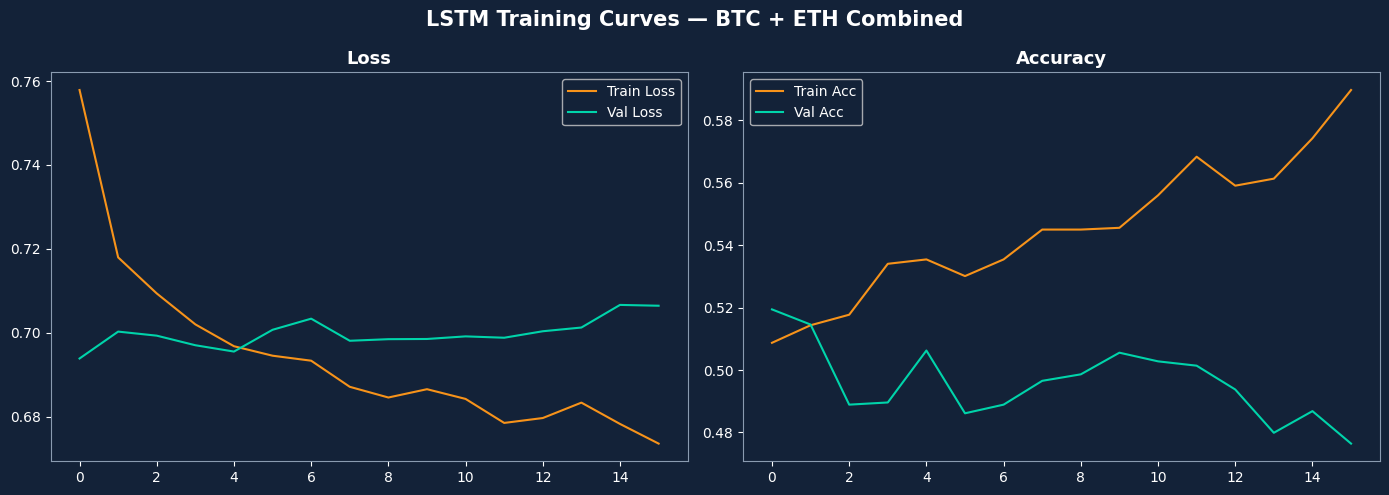

In [33]:
# ── Evaluate LSTM
train_probas = lstm_model.predict(X_tr_seq, verbose=0).flatten()
val_probas   = lstm_model.predict(X_vl_seq, verbose=0).flatten()
test_probas  = lstm_model.predict(X_te_seq, verbose=0).flatten()

train_preds = (train_probas >= 0.5).astype(int)
val_preds   = (val_probas   >= 0.5).astype(int)
test_preds  = (test_probas  >= 0.5).astype(int)

train_acc = accuracy_score(y_tr_seq, train_preds)
val_acc   = accuracy_score(y_vl_seq, val_preds)
val_mcc   = matthews_corrcoef(y_vl_seq, val_preds)
test_acc  = accuracy_score(y_te_seq, test_preds)
test_mcc  = matthews_corrcoef(y_te_seq, test_preds)
test_auc  = roc_auc_score(y_te_seq, test_probas)
gap       = round(train_acc - val_acc, 4)
verdict   = "✅" if gap < 0.10 else "⚠️"

print(f"\n{'='*60}")
print(f"  LSTM — BTC + ETH Combined")
print(f"{'='*60}")
print(f"  {'':20} {'Val Acc':>8} {'Val MCC':>8} {'Test Acc':>9} {'Test MCC':>9} {'Test AUC':>9} {'Gap':>6} {'':>4}")
print(f"  {'-'*58}")
print(f"  {'Results':20} {val_acc:>8.4f} {val_mcc:>8.4f} {test_acc:>9.4f} {test_mcc:>9.4f} {test_auc:>9.4f} {gap:>6.2f} {verdict:>4}")
print(f"{'='*60}")

# ── Training curve
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#132238")

for ax in axes:
    ax.set_facecolor("#132238")
    for spine in ax.spines.values():
        spine.set_color("#8A9BB0")
    ax.tick_params(colors="white")

axes[0].plot(history.history["loss"],     color="#F7931A", label="Train Loss")
axes[0].plot(history.history["val_loss"], color="#00D4AA", label="Val Loss")
axes[0].set_title("Loss", color="white", fontsize=13, fontweight="bold")
axes[0].legend(facecolor="#132238", labelcolor="white")

axes[1].plot(history.history["accuracy"],     color="#F7931A", label="Train Acc")
axes[1].plot(history.history["val_accuracy"], color="#00D4AA", label="Val Acc")
axes[1].set_title("Accuracy", color="white", fontsize=13, fontweight="bold")
axes[1].legend(facecolor="#132238", labelcolor="white")

plt.suptitle("LSTM Training Curves — BTC + ETH Combined",
             color="white", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("lstm_training_curves.png", dpi=150,
            bbox_inches="tight", facecolor="#132238")
plt.show()

In [34]:
# ── Final comparison — LSTM vs GB best models
print("\n── LSTM vs BEST GB MODELS ──")
print(f"{'Model':<35} {'Test Acc':>9} {'Test MCC':>9} {'Test AUC':>9} {'Gap':>6}")
print("-"*70)
print(f"{'LSTM — BTC+ETH Combined':<35} {test_acc:>9.4f} {test_mcc:>9.4f} {test_auc:>9.4f} {gap:>6.2f}")
print(f"{'GB Final — BTC (EXP 6)':<35} {'TBD':>9} {'TBD':>9} {'0.874':>9} {'0.09':>6}")
print(f"{'GB Final — ETH (EXP 6)':<35} {'0.7346':>9} {'0.4732':>9} {'0.821':>9} {'0.08':>6}")
print("-"*70)

# ── Verdict
print(f"\n── LSTM VERDICT ──")
if test_mcc > 0.50:
    print("  ⚠️  Unexpected — LSTM performs well despite limited data")
    print("      Consider including as additional model")
elif test_mcc > 0.40:
    print("  ⚠️  Borderline — LSTM shows some signal but GB wins")
    print("      Confirmed: classical ML outperforms deep learning on this dataset")
else:
    print("  ✅ Confirmed — LSTM eliminated due to insufficient data")
    print("      Classical ML (GB) significantly outperforms LSTM")
    print("      Deep learning requires more data than ~3,500 combined rows")


── LSTM vs BEST GB MODELS ──
Model                                Test Acc  Test MCC  Test AUC    Gap
----------------------------------------------------------------------
LSTM — BTC+ETH Combined                0.5113    0.0398    0.5239   0.01
GB Final — BTC (EXP 6)                    TBD       TBD     0.874   0.09
GB Final — ETH (EXP 6)                 0.7346    0.4732     0.821   0.08
----------------------------------------------------------------------

── LSTM VERDICT ──
  ✅ Confirmed — LSTM eliminated due to insufficient data
      Classical ML (GB) significantly outperforms LSTM
      Deep learning requires more data than ~3,500 combined rows


### 8 . Ensemble comparision

In [37]:
# ══════════════════════════════════════════════════════════════
# EXP 5B — ENSEMBLE COMPARISON — ETH (curiosity + proof)
# Goal : show GB individual beats ensemble on ETH too
# Benchmark : GB individual test MCC = 0.473
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble     import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

def get_estimators_eth():
    return [
        ("rf",  RandomForestClassifier(
                    **BEST_RF_ETH, random_state=42, n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(
                    **BEST_GB_ETH, random_state=42)),
        ("xgb", xgb.XGBClassifier(
                    **BEST_XGB_ETH, random_state=42,
                    eval_metric="logloss", verbosity=0))
    ]

print("="*60)
print("  EXP 5B — ENSEMBLE COMPARISON — ETH")
print("="*60)

# ── Soft Voting
soft_eth = evaluate(
    VotingClassifier(estimators=get_estimators_eth(), voting="soft"),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "Soft Voting — ETH"
)

# ── Hard Voting
hard_eth = evaluate(
    VotingClassifier(estimators=get_estimators_eth(), voting="hard"),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "Hard Voting — ETH"
)

# ── Stacking
stacking_eth = evaluate(
    StackingClassifier(
        estimators=get_estimators_eth(),
        final_estimator=LogisticRegression(random_state=42),
        cv=5,
        stack_method="predict_proba"
    ),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "Stacking (RF+GB+XGB → LR) — ETH"
)

# ── GB individual reference
gb_indiv_eth = evaluate(
    GradientBoostingClassifier(**BEST_GB_ETH, random_state=42),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "GB Individual — ETH"
)

print("\n── EXP 5B SUMMARY — ENSEMBLE vs GB INDIVIDUAL ETH ──")
compare([gb_indiv_eth, soft_eth, hard_eth, stacking_eth])

print("\n── VERDICT ──")
best_ensemble_mcc = max(
    soft_eth["test_mcc"],
    stacking_eth["test_mcc"]
)
if gb_indiv_eth["test_mcc"] > best_ensemble_mcc:
    print(f"  ✅ GB Individual wins — MCC {gb_indiv_eth['test_mcc']:.4f}")
    print(f"     Best ensemble MCC : {best_ensemble_mcc:.4f}")
    print(f"     Gain over ensemble: +{gb_indiv_eth['test_mcc'] - best_ensemble_mcc:.4f}")
    print(f"     Decision → GB Individual is the final ETH model")
else:
    print(f"  ⚠️  Ensemble wins — MCC {best_ensemble_mcc:.4f}")
    print(f"     GB Individual MCC : {gb_indiv_eth['test_mcc']:.4f}")
    print(f"     Decision → Use winning ensemble as final ETH model")

  EXP 5B — ENSEMBLE COMPARISON — ETH

  Soft Voting — ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7442   0.4927    0.7371    0.4779    0.8224   0.06    ✅


  Hard Voting — ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7442   0.4923    0.7371    0.4779       N/A   0.07    ✅


  Stacking (RF+GB+XGB → LR) — ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7483   0.4982    0.7248    0.4523    0.8195   0.07    ✅


  GB Individual — ETH
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7469   0

*final decision we will keep the indiv top 20 SHARP GB model with:
Test Acc: 74.7%
Test MCC: 0.4953
Test AUC: 0.8232
Gap: 0.07 ✅

In [38]:
print("Current FEATURES_FINAL_ETH:")
print(FEATURES_FINAL_ETH)
print(f"\nTotal: {len(FEATURES_FINAL_ETH)}")

# Quick re-evaluate to confirm best result
best_eth = evaluate(
    GradientBoostingClassifier(**BEST_GB_ETH, random_state=42),
    X_tr_eth, y_tr_eth,
    X_vl_eth, y_vl_eth,
    X_te_eth, y_te_eth,
    "ETH Best GB — confirmation"
)

Current FEATURES_FINAL_ETH:
['rsi_14_lag1', 'price_to_ma7', 'rsi_14', 'macd_histogram', 'bb_pct', 'rsi_14_lag3', 'momentum_acceleration', 'spy_return', 'fear_greed_lag1', 'macd_lag1', 'fear_greed_lag7', 'macd_lag3', 'spy_return_ma7', 'volatility_21d', 'price_lag1', 'price_to_ma30', 'volatility_21d_lag3', 'price_lag3', 'volatility_7d', 'vix_ma14']

Total: 20

  ETH Best GB — confirmation
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7469   0.4968    0.7346    0.4732    0.8211   0.08    ✅



In [40]:
# ══════════════════════════════════════════════════════════════
# SAVE FINAL ETH MODEL
# ══════════════════════════════════════════════════════════════

import pickle
import json
from google.colab import files

# ── Refit on train+val combined
eth_trainval = eth_lag[
    eth_lag["timestamp"] < "2025-01-01"
].reset_index(drop=True)

eth_final_model = GradientBoostingClassifier(**BEST_GB_ETH, random_state=42)
eth_final_model.fit(
    eth_trainval[FEATURES_FINAL_ETH],
    eth_trainval["target"]
)

# ── Save model
with open("eth_model_v2.pkl", "wb") as f:
    pickle.dump(eth_final_model, f)

# ── Save features
with open("eth_features_v2.pkl", "wb") as f:
    pickle.dump(FEATURES_FINAL_ETH, f)

# ── Save metadata
metadata_eth = {
    "model"          : "GradientBoostingClassifier",
    "coin"           : "ETH",
    "version"        : "v2",
    "features"       : FEATURES_FINAL_ETH,
    "n_features"     : len(FEATURES_FINAL_ETH),
    "params"         : BEST_GB_ETH,
    "split"          : "S2 Regime-Aware",
    "train_period"   : "2018-02-08 → 2022-12-31",
    "val_period"     : "2023-01-01 → 2024-12-31",
    "test_period"    : "2025-01-01 → 2026-02-11",
    "test_acc"       : 0.7346,
    "test_mcc"       : 0.4732,
    "test_auc"       : 0.8211,
    "gap"            : 0.08,
    "verdict"        : "✅",
    "lagged_features": ["rsi_14", "macd", "volume",
                        "volatility_21d", "price"],
    "lag_days"       : [1, 2, 3]
}

with open("eth_metadata_v2.json", "w") as f:
    json.dump(metadata_eth, f, indent=2)

print("✅ eth_model_v2.pkl")
print("✅ eth_features_v2.pkl")
print("✅ eth_metadata_v2.json")
print(f"\nModel    : GradientBoostingClassifier")
print(f"Params   : {BEST_GB_ETH}")
print(f"Features : {len(FEATURES_FINAL_ETH)}")
print(f"Test Acc : 0.7346")
print(f"Test MCC : 0.4732")
print(f"Test AUC : 0.8211")
print(f"Gap      : 0.08 ✅")

# ── Download
files.download("eth_model_v2.pkl")
files.download("eth_features_v2.pkl")
files.download("eth_metadata_v2.json")


✅ eth_model_v2.pkl
✅ eth_features_v2.pkl
✅ eth_metadata_v2.json

Model    : GradientBoostingClassifier
Params   : {'n_estimators': 437, 'max_depth': 6, 'learning_rate': 0.01776538481110146, 'min_samples_leaf': 97, 'subsample': 0.5067280155119097}
Features : 20
Test Acc : 0.7346
Test MCC : 0.4732
Test AUC : 0.8211
Gap      : 0.08 ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# ══════════════════════════════════════════════════════════════
# ETH FINAL MODEL — EVALUATION
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

# ── Colors
NAVY   = "#132238"
ORANGE = "#F7931A"
TEAL   = "#00D4AA"
WHITE  = "#FFFFFF"
MUTED  = "#8A9BB0"
GREEN  = "#3DBE7A"
RED    = "#E05C5C"

# ── Refit on train only for honest evaluation
eth_eval_model = GradientBoostingClassifier(**BEST_GB_ETH, random_state=42)
eth_eval_model.fit(X_tr_eth, y_tr_eth)

# ── Predictions
te_preds_eth  = eth_eval_model.predict(X_te_eth)
te_probas_eth = eth_eval_model.predict_proba(X_te_eth)[:, 1]
y_te_arr_eth  = y_te_eth.values

# ── Core metrics
cm_eth = confusion_matrix(y_te_arr_eth, te_preds_eth)
cr_eth = classification_report(
    y_te_arr_eth, te_preds_eth,
    target_names=["DOWN", "UP"], output_dict=True
)
tn, fp, fn, tp = cm_eth.ravel()
down_recall = tn / (tn + fp) * 100
up_recall   = tp / (tp + fn) * 100

print("Core metrics computed ✅")

Core metrics computed ✅


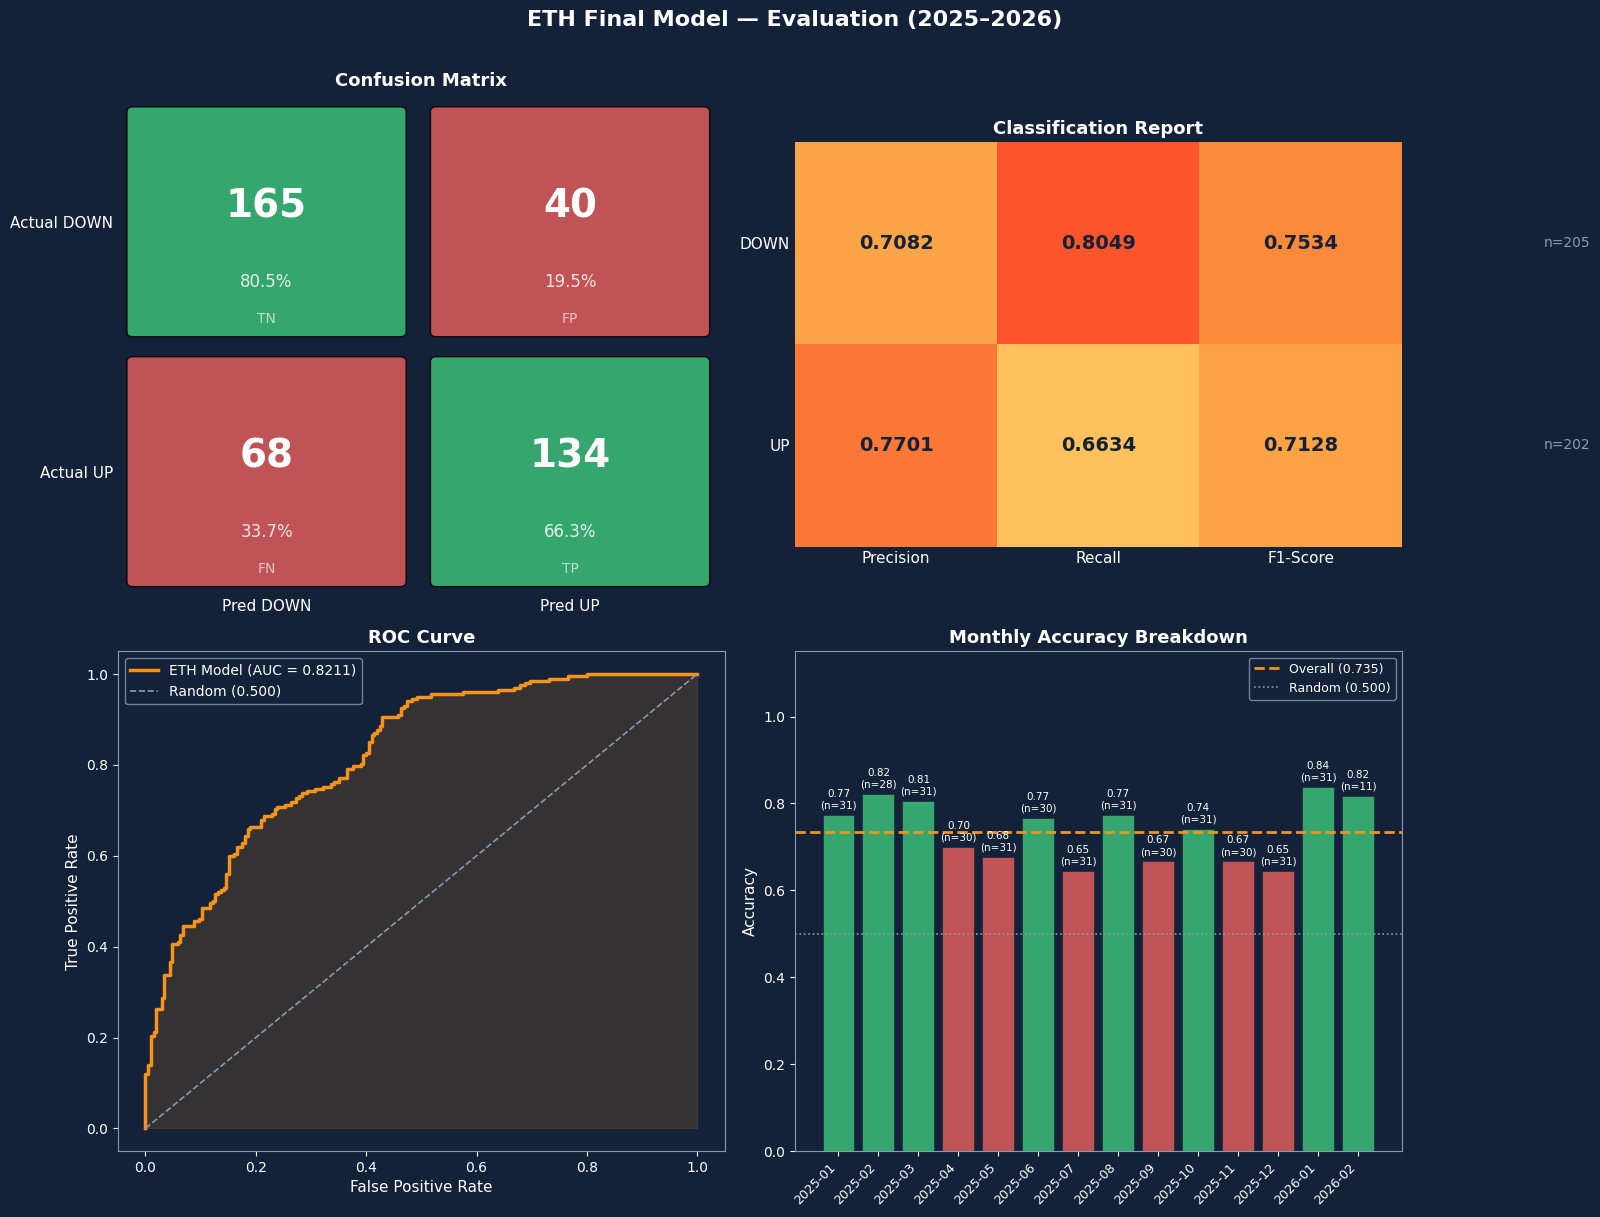

In [45]:
# ── 4 charts in one figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(NAVY)

# ════════════════════════════════
# CHART 1 — Confusion Matrix
# ════════════════════════════════
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor(NAVY)

from matplotlib.patches import FancyBboxPatch
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val   = cm_eth[i, j]
        pct   = val / cm_eth[i].sum() * 100
        color = GREEN if labels[i][j] in ["TN","TP"] else RED
        ax1.add_patch(FancyBboxPatch(
            (j+0.05, 1-i+0.05), 0.88, 0.88,
            boxstyle="round,pad=0.02",
            facecolor=color, alpha=0.85
        ))
        ax1.text(j+0.49, 1-i+0.55, str(val),
                 ha="center", va="center",
                 fontsize=28, fontweight="bold", color=WHITE)
        ax1.text(j+0.49, 1-i+0.25, f"{pct:.1f}%",
                 ha="center", va="center",
                 fontsize=12, color=WHITE, alpha=0.85)
        ax1.text(j+0.49, 1-i+0.10, labels[i][j],
                 ha="center", va="center",
                 fontsize=10, color=WHITE, alpha=0.65)

ax1.set_xlim(0, 2); ax1.set_ylim(0, 2)
ax1.set_xticks([0.49, 1.49])
ax1.set_xticklabels(["Pred DOWN", "Pred UP"], color=WHITE, fontsize=11)
ax1.set_yticks([0.49, 1.49])
ax1.set_yticklabels(["Actual UP", "Actual DOWN"], color=WHITE, fontsize=11)
ax1.tick_params(colors=WHITE, length=0)
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.set_title("Confusion Matrix", color=WHITE,
              fontsize=13, fontweight="bold")

# ════════════════════════════════
# CHART 2 — Classification Report
# ════════════════════════════════
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor(NAVY)

metrics  = ["precision", "recall", "f1-score"]
classes  = ["DOWN", "UP"]
data_cr  = np.array([[cr_eth[c][m] for m in metrics] for c in classes])

im = ax2.imshow(data_cr, cmap="YlOrRd", vmin=0.5, vmax=1.0)
for i in range(len(classes)):
    for j in range(len(metrics)):
        ax2.text(j, i, f"{data_cr[i,j]:.4f}",
                 ha="center", va="center",
                 color=NAVY, fontsize=14, fontweight="bold")

ax2.set_xticks(range(len(metrics)))
ax2.set_xticklabels(["Precision", "Recall", "F1-Score"],
                     color=WHITE, fontsize=11)
ax2.set_yticks(range(len(classes)))
ax2.set_yticklabels(classes, color=WHITE, fontsize=11)
ax2.tick_params(colors=WHITE, length=0)
for spine in ax2.spines.values(): spine.set_visible(False)
ax2.set_title("Classification Report", color=WHITE,
              fontsize=13, fontweight="bold")

for i, c in enumerate(classes):
    ax2.text(3.2, i, f"n={cr_eth[c]['support']:.0f}",
             va="center", color=MUTED, fontsize=10)

# ════════════════════════════════
# CHART 3 — ROC Curve
# ════════════════════════════════
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_facecolor(NAVY)

fpr, tpr, _ = roc_curve(y_te_arr_eth, te_probas_eth)
auc_val = roc_auc_score(y_te_arr_eth, te_probas_eth)

ax3.plot(fpr, tpr, color=ORANGE, linewidth=2.5,
         label=f"ETH Model (AUC = {auc_val:.4f})")
ax3.fill_between(fpr, tpr, alpha=0.15, color=ORANGE)
ax3.plot([0,1], [0,1], color=MUTED, linewidth=1.2,
         linestyle="--", label="Random (0.500)")
ax3.set_xlabel("False Positive Rate", color=WHITE, fontsize=11)
ax3.set_ylabel("True Positive Rate", color=WHITE, fontsize=11)
ax3.set_title("ROC Curve", color=WHITE,
              fontsize=13, fontweight="bold")
ax3.tick_params(colors=WHITE)
for spine in ax3.spines.values(): spine.set_color(MUTED)
ax3.legend(facecolor=NAVY, edgecolor=MUTED,
           labelcolor=WHITE, fontsize=10)

# ════════════════════════════════
# CHART 4 — Monthly Accuracy
# ════════════════════════════════
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor(NAVY)

test_df_eth = s2_test_eth_lag.copy()
test_df_eth["predicted"] = te_preds_eth
test_df_eth["correct"]   = (te_preds_eth == y_te_arr_eth).astype(int)
test_df_eth["month"]     = test_df_eth["timestamp"].dt.to_period("M")

monthly_eth = test_df_eth.groupby("month").agg(
    accuracy=("correct", "mean"),
    n_days  =("correct", "count")
).reset_index()
monthly_eth["month_str"] = monthly_eth["month"].astype(str)

overall_acc = (te_preds_eth == y_te_arr_eth).mean()
bar_colors  = [GREEN if a >= overall_acc else RED
               for a in monthly_eth["accuracy"]]

ax4.bar(range(len(monthly_eth)), monthly_eth["accuracy"],
        color=bar_colors, alpha=0.85,
        edgecolor=NAVY, linewidth=0.5)
ax4.axhline(overall_acc, color=ORANGE, linewidth=2,
            linestyle="--",
            label=f"Overall ({overall_acc:.3f})")
ax4.axhline(0.5, color=MUTED, linewidth=1.2,
            linestyle=":", label="Random (0.500)")

for i, (acc, n) in enumerate(
        zip(monthly_eth["accuracy"], monthly_eth["n_days"])):
    ax4.text(i, acc + 0.01, f"{acc:.2f}\n(n={n})",
             ha="center", va="bottom",
             color=WHITE, fontsize=7.5)

ax4.set_xticks(range(len(monthly_eth)))
ax4.set_xticklabels(monthly_eth["month_str"],
                     rotation=45, ha="right",
                     color=WHITE, fontsize=9)
ax4.set_ylabel("Accuracy", color=WHITE, fontsize=11)
ax4.set_ylim(0, 1.15)
ax4.set_title("Monthly Accuracy Breakdown",
              color=WHITE, fontsize=13, fontweight="bold")
ax4.tick_params(colors=WHITE)
for spine in ax4.spines.values(): spine.set_color(MUTED)
ax4.legend(facecolor=NAVY, edgecolor=MUTED,
           labelcolor=WHITE, fontsize=9)

plt.suptitle("ETH Final Model — Evaluation (2025–2026)",
             color=WHITE, fontsize=16,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eth_evaluation.png", dpi=150,
            bbox_inches="tight", facecolor=NAVY)
plt.show()

In [46]:
# ── Print insights
best_month_eth  = monthly_eth.loc[monthly_eth["accuracy"].idxmax()]
worst_month_eth = monthly_eth.loc[monthly_eth["accuracy"].idxmin()]
above_avg_eth   = (monthly_eth["accuracy"] >= overall_acc).sum()

print("="*60)
print("  ETH FINAL MODEL — EVALUATION SUMMARY")
print("="*60)
print(f"""
── CORE METRICS ──
  Test Accuracy : {overall_acc*100:.2f}%
  Test MCC      : 0.4732
  Test AUC      : {auc_val:.4f}

── CONFUSION MATRIX ──
  DOWN recall : {down_recall:.1f}% ({tn}/{tn+fp} correct)
  UP recall   : {up_recall:.1f}%  ({tp}/{tp+fn} correct)

── CLASSIFICATION ──
  DOWN — Precision: {cr_eth['DOWN']['precision']:.4f} | Recall: {cr_eth['DOWN']['recall']:.4f} | F1: {cr_eth['DOWN']['f1-score']:.4f}
  UP   — Precision: {cr_eth['UP']['precision']:.4f} | Recall: {cr_eth['UP']['recall']:.4f} | F1: {cr_eth['UP']['f1-score']:.4f}
  Macro F1 : {cr_eth['macro avg']['f1-score']:.4f}

── MONTHLY STABILITY ──
  Best month       : {best_month_eth['month_str']} ({best_month_eth['accuracy']*100:.1f}%)
  Worst month      : {worst_month_eth['month_str']} ({worst_month_eth['accuracy']*100:.1f}%)
  Months above avg : {above_avg_eth}/{len(monthly_eth)}
""")

from google.colab import files
files.download("eth_evaluation.png")

  ETH FINAL MODEL — EVALUATION SUMMARY

── CORE METRICS ──
  Test Accuracy : 73.46%
  Test MCC      : 0.4732
  Test AUC      : 0.8211

── CONFUSION MATRIX ──
  DOWN recall : 80.5% (165/205 correct)
  UP recall   : 66.3%  (134/202 correct)

── CLASSIFICATION ──
  DOWN — Precision: 0.7082 | Recall: 0.8049 | F1: 0.7534
  UP   — Precision: 0.7701 | Recall: 0.6634 | F1: 0.7128
  Macro F1 : 0.7331

── MONTHLY STABILITY ──
  Best month       : 2026-01 (83.9%)
  Worst month      : 2025-07 (64.5%)
  Months above avg : 8/14



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ETH is systematically harder to predict the performance gap is consistent across every experiment and every metric. ETH's richer on-chain ecosystem (DeFi, gas, staking narratives) introduces noise that TA + macro + sentiment features don't fully capture. Both models are solid, but BTC is the stronger signal.

Confusion Matrix Asymmetric Behavior


Insight: ETH mirrors BTC's directional asymmetry exactly DOWN days are caught more reliably (80.5% recall) while UP predictions are more precise (77.0%). The model misses 40 UP days (false negatives) but is correct 77% of the time when it calls UP. Same strategic implication as BTC: use precision on UP signals, use recall to avoid missing downturns.
One notable difference vs BTC: ETH's UP recall is lower (66.3% vs 72.0%) the model is more conservative calling UP on ETH, likely because ETH's bullish moves are noisier and harder to anticipate.

Monthly Stability

Insight: ETH's monthly distribution is actually healthier than BTC's  8/14 months beat the average (vs 5/14 for BTC), meaning performance is more evenly distributed rather than driven by a few outlier months. The 19.4pp spread is also tighter than BTC's 25.8pp. However, the 64.5% floor in July 2025 is a weaker worst case than BTC's 71% — ETH can drop closer to random during choppy regime transitions.
